# Upper Florida Keys Water Quality Analysis

## Overview

This notebook retrieves, processes, and visualizes in-situ water quality data for the Upper Florida Keys estuary
over the period 2015-2024. 

### Pip Install & Imports

In [29]:
pip install pymannkendall

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import requests
import pandas as pd
from io import StringIO
import geopandas as gpd
from shapely.geometry import Point
import geopandas as gpd
import rasterio as rio
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
from scipy import stats
import pymannkendall as mk
from pymannkendall import original_test as mk_test

### Data Download: 

Query the WQP API for relative parameter across ocean / estuary sites within the bounding box "-80.65, 24.85, -80.20, 25.35." \
Parameters: Turbidity, Salinity, Temperature, Secchi Disk Depth, Chlorophyll-a

In [46]:
url = "https://www.waterqualitydata.us/data/Result/search"

params = {
    "bBox": "-80.65,24.85,-80.20,25.35",
    "siteType": "Estuary",
    "startDateLo": "01-01-2015",
    "startDateHi": "12-31-2024",
    "sampleMedia": "Water",
    "characteristicName": [
        "Turbidity",
        "Salinity",
        "Temperature, water",
        "Chlorophyll a",
        "Depth, Secchi disk depth"
    ],
    "mimeType": "csv"
}

print("Downloading Upper Keys water quality results...")
response = requests.get(url, params=params)
print(f"Status: {response.status_code}")

if response.status_code == 200:
    df_wq = pd.read_csv(StringIO(response.text))
    print(f"Total rows: {df_wq.shape[0]}")
    print(f"Columns: {df_wq.columns.tolist()}")
    print(df_wq.head())
    
    # Save
    df_wq.to_csv("upper_keys_results.csv", index=False)
    print("Saved as upper_keys_results.csv")
else:
    print(f"Error: {response.text[:500]}")

Status: 200
Total rows: 8056
Columns: ['OrganizationIdentifier', 'OrganizationFormalName', 'ActivityIdentifier', 'ActivityTypeCode', 'ActivityMediaName', 'ActivityMediaSubdivisionName', 'ActivityStartDate', 'ActivityStartTime/Time', 'ActivityStartTime/TimeZoneCode', 'ActivityEndDate', 'ActivityEndTime/Time', 'ActivityEndTime/TimeZoneCode', 'ActivityDepthHeightMeasure/MeasureValue', 'ActivityDepthHeightMeasure/MeasureUnitCode', 'ActivityDepthAltitudeReferencePointText', 'ActivityTopDepthHeightMeasure/MeasureValue', 'ActivityTopDepthHeightMeasure/MeasureUnitCode', 'ActivityBottomDepthHeightMeasure/MeasureValue', 'ActivityBottomDepthHeightMeasure/MeasureUnitCode', 'ProjectIdentifier', 'ActivityConductingOrganizationText', 'MonitoringLocationIdentifier', 'ActivityCommentText', 'SampleAquifer', 'HydrologicCondition', 'HydrologicEvent', 'SampleCollectionMethod/MethodIdentifier', 'SampleCollectionMethod/MethodIdentifierContext', 'SampleCollectionMethod/MethodName', 'SampleCollectionEquipmentN

In [47]:
display(df_wq.head())

,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,...,ResultAnalyticalMethod/MethodName,MethodDescriptionText,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure/MeasureValue,DetectionQuantitationLimitMeasure/MeasureUnitCode,PreparationStartDate,ProviderName
0,21FLWQA_WQX,FDEP Watershed Assessment Section (WAS),21FLWQA_WQX-G5AA0008-11/23/20,Sample-Routine,Water,Surface Water,2020-11-23,13:16:00,EST,2020-11-23,...,Turbidity by Nephelometry,https://www.nemi.gov/methods/method_summary/5217/,E31780,2020-11-24,NaN,Practical Quantitation Limit,0.13,NTU,NaN,STORET
1,21FLDADE_WQX,Dade Environmental Resource Management (Florida),21FLDADE_WQX-BB48-0720S,Field Msr/Obs,Water,Surface Water,2020-07-22,09:19:00,EDT,NaN,...,FDEP FT1300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
2,21FLSFWM_WQX,South Florida Water Management District,21FLSFWM_WQX-P118758-7F,Field Msr/Obs,Water,Surface Water,2020-11-12,11:36:00,EDT,NaN,...,SFWMD FSQM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
3,21FLDADE_WQX,Dade Environmental Resource Management (Florida),21FLDADE_WQX-BB47-0120YB,Field Msr/Obs,Water,Surface Water,2020-01-08,09:07:00,EDT,NaN,...,FDEP FT1400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET
4,21FLSFWM_WQX,South Florida Water Management District,21FLSFWM_WQX-P111062-6F,Field Msr/Obs,Water,Surface Water,2020-08-17,10:19:00,EDT,NaN,...,SFWMD FSQM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET


### Pivot Table

Creates a new data table that pivots the relative parameters into columns. Index by datetime. 

In [48]:
# Extract units per characteristic
units = (
    df_wq.groupby("CharacteristicName")["ResultMeasure/MeasureUnitCode"]
    .agg(lambda x: x.dropna().mode()[0] if x.dropna().any() else "")
    .to_dict()
)
print("Units found:", units)

# Build rename map with units
rename_map = {
    "Temperature, water":       f"Temperature ({units.get('Temperature, water', '°C')})",
    "Depth, Secchi disk depth": f"Secchi Depth ({units.get('Depth, Secchi disk depth', 'm')})",
    "Chlorophyll a":            f"Chlorophyll_a ({units.get('Chlorophyll a', 'µg/L')})",
    "Turbidity":                f"Turbidity ({units.get('Turbidity', 'NTU')})",
    "Salinity":                 f"Salinity ({units.get('Salinity', 'ppt')})",
}

# Pivot parameters into columns
df_wq["ResultMeasureValue"] = pd.to_numeric(df_wq["ResultMeasureValue"], errors="coerce")

df_pivot = df_wq.groupby(
    ["ActivityStartDate", "MonitoringLocationIdentifier", "CharacteristicName"]
)["ResultMeasureValue"].mean().unstack("CharacteristicName").reset_index()

df_pivot.columns.name = None

# Apply rename with units baked in
df_pivot = df_pivot.rename(columns=rename_map)

# Set clean datetime index
df_pivot["ActivityStartDate"] = pd.to_datetime(df_pivot["ActivityStartDate"])
df_pivot = df_pivot.set_index("ActivityStartDate").sort_index()

print(f"\nPivoted shape: {df_pivot.shape}")
print(f"Columns: {df_pivot.columns.tolist()}")
print(df_pivot.head())

# Save
df_pivot.to_csv("upper_keys_pivot.csv")
print("Saved as upper_keys_pivot.csv")
display(df_pivot.head())

Units found: {'Depth, Secchi disk depth': 'm', 'Salinity': 'PSS', 'Temperature, water': 'deg C', 'Turbidity': 'NTU'}

Pivoted shape: (1749, 5)
Columns: ['MonitoringLocationIdentifier', 'Secchi Depth (m)', 'Salinity (PSS)', 'Temperature (deg C)', 'Turbidity (NTU)']
                  MonitoringLocationIdentifier  Secchi Depth (m)  \
ActivityStartDate                                                  
2015-01-07                   21FLDADE_WQX-BB47               NaN   
2015-01-07                   21FLDADE_WQX-BB50               NaN   
2015-01-07                   21FLDADE_WQX-BB51               NaN   
2015-02-03                   21FLSFWM_WQX-6598               2.5   
2015-02-03                   21FLSFWM_WQX-6599               1.6   

                   Salinity (PSS)  Temperature (deg C)  Turbidity (NTU)  
ActivityStartDate                                                        
2015-01-07              33.746667            25.330000              0.5  
2015-01-07              30.970000   

,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU)
ActivityStartDate,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8
2015-01-07,21FLDADE_WQX-BB51,NaN,30.806667,25.396667,0.4
2015-02-03,21FLSFWM_WQX-6598,2.5,35.000000,21.000000,1.8
2015-02-03,21FLSFWM_WQX-6599,1.6,32.800000,21.500000,2.2


### Check total parameter count

In [49]:
# Check all parameters and their counts
print("Parameters in dataset:")
print(df_wq["CharacteristicName"].value_counts())

print(f"\nTotal unique parameters: {df_wq['CharacteristicName'].nunique()}")

Parameters in dataset:
CharacteristicName
Salinity                    2696
Temperature, water          2693
Turbidity                   1574
Depth, Secchi disk depth    1093
Name: count, dtype: int64

Total unique parameters: 4


### Build GeoDataFrame 

Pulls station metadata to match Latitude and Longitude coordinates to stations, \
and merges those coordinates into the pivot table. With Latitude and Longitude coordinates \
the water quality data can be paired to a shapefile of relevant study area. 

In [50]:
# Download station metadata (coordinates)
station_url = "https://www.waterqualitydata.us/data/Station/search"
station_params = {
    "bBox": "-80.65,24.85,-80.20,25.35",
    "siteType": "Estuary",
    "mimeType": "csv"
}
stations = pd.read_csv(
    StringIO(requests.get(station_url, params=station_params).text)
)

print(f"Stations loaded: {stations.shape[0]}")

# Merge coordinates into df_pivot
df_pivot_geo = df_pivot.reset_index().merge(
    stations[[
        "MonitoringLocationIdentifier",
        "LatitudeMeasure",
        "LongitudeMeasure"
    ]].drop_duplicates("MonitoringLocationIdentifier"),
    on="MonitoringLocationIdentifier",
    how="left"
).rename(columns={
    "LatitudeMeasure": "Latitude",
    "LongitudeMeasure": "Longitude"
})

missing = df_pivot_geo["Latitude"].isna().sum()
print(f"Rows missing coordinates: {missing}")


#Build GeoDataFrame
df_pivot_geo = df_pivot_geo.dropna(subset=["Latitude", "Longitude"])

geometry = [Point(xy) for xy in zip(df_pivot_geo["Longitude"], df_pivot_geo["Latitude"])]
wq_gdf = gpd.GeoDataFrame(df_pivot_geo, geometry=geometry)

# WGS84 since coordinates come from the API as decimal degrees
wq_gdf = wq_gdf.set_crs("EPSG:4326")

# Reproject to match shapefile
reef_shape = gpd.read_file("UpperKeys_FL.shp")
print(f"Shapefile CRS: {reef_shape.crs}")
wq_gdf = wq_gdf.to_crs(reef_shape.crs)

# Restore date index
wq_gdf = wq_gdf.set_index("ActivityStartDate").sort_index()
wq_gdf.index.name = "Date"

print(f"\nFinal GeoDataFrame shape: {wq_gdf.shape}")
display(wq_gdf.head())

Stations loaded: 2102
Rows missing coordinates: 0
Shapefile CRS: PROJCS["NAD_1983_Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",24],PARAMETER["longitude_of_center",-84],PARAMETER["standard_parallel_1",24],PARAMETER["standard_parallel_2",31.5],PARAMETER["false_easting",400000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]

Final GeoDataFrame shape: (1749, 8)


,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU),Latitude,Longitude,geometry
Date,,,,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5,25.336794,-80.320077,POINT (769962.142 153691.31)
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8,25.229898,-80.376777,POINT (764611.659 141671.903)
2015-01-07,21FLDADE_WQX-BB51,NaN,30.806667,25.396667,0.4,25.251496,-80.414079,POINT (760789.398 143956.507)
2015-02-03,21FLSFWM_WQX-6598,2.5,35.000000,21.000000,1.8,25.174050,-80.423081,POINT (760133.028 135344.954)
2015-02-03,21FLSFWM_WQX-6599,1.6,32.800000,21.500000,2.2,25.206681,-80.440400,POINT (758285.307 138911.686)


# Visulization 



### Monitoring stations paired with shpaefile

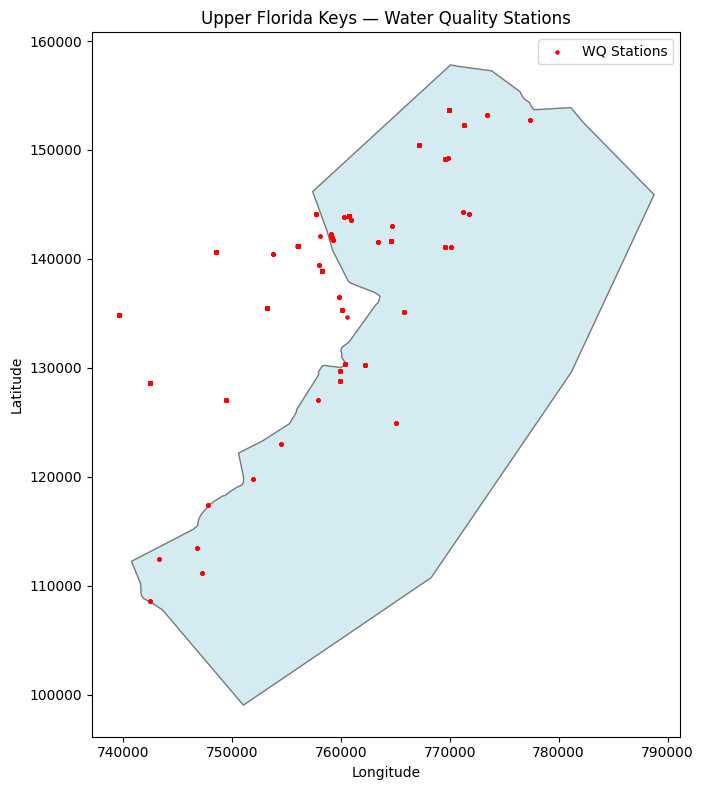

In [51]:
fig, ax = plt.subplots(figsize=(10, 8))

reef_shape.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)
wq_gdf.to_crs(reef_shape.crs).plot(ax=ax, color='red', markersize=5, label='WQ Stations')

plt.title("Upper Florida Keys — Water Quality Stations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

### Define parameters

In [121]:

# Define your parameter columns (adjust names to match yours with units)
param_cols = [col for col in wq_gdf.columns if any(p in col for p in 
              ["Temperature", "Salinity", "Turbidity", "Secchi", "Chlorophyll"])]

### Correlation Matrix

Shows the strength of the relationship between parameters. (Top half of this matrix is mirrored)

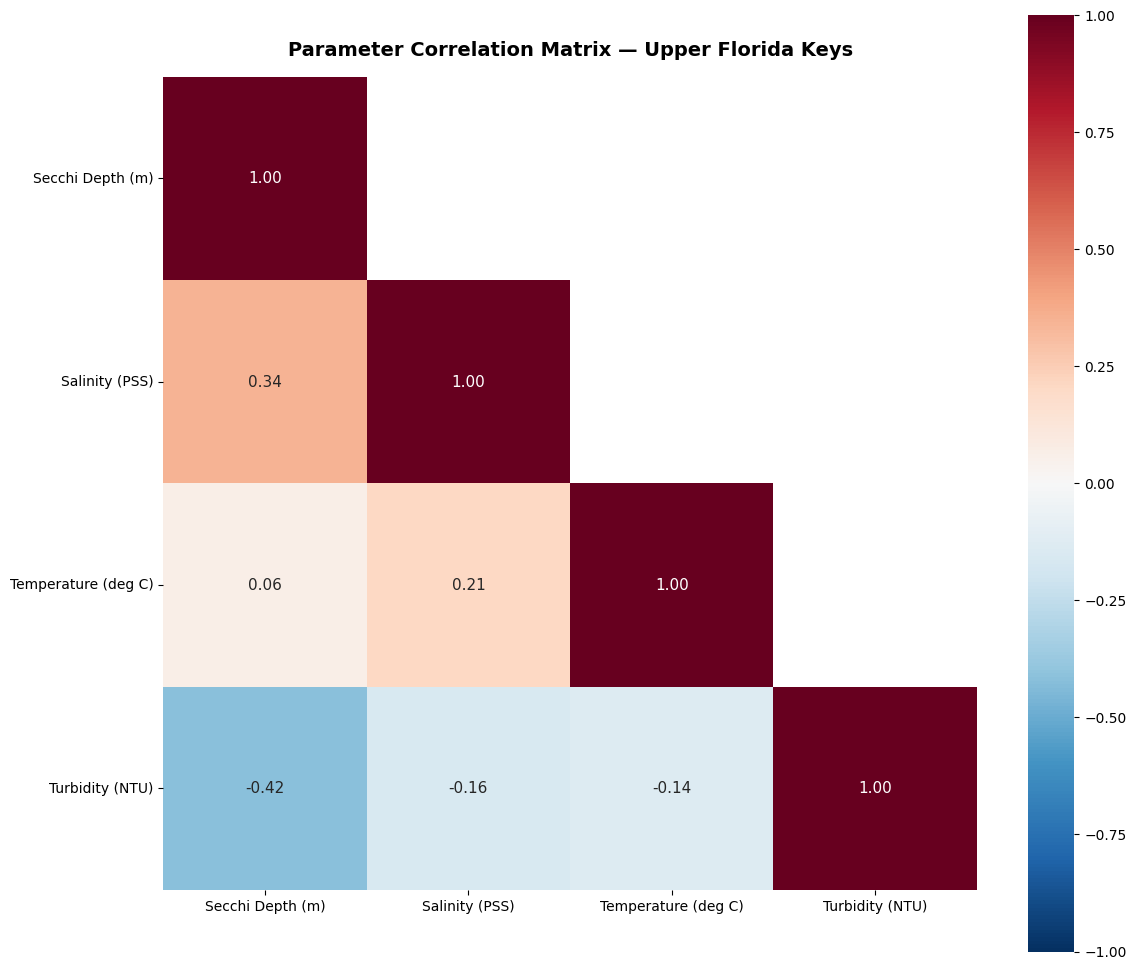

In [53]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = wq_gdf[param_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0,        # no gaps
            square=True,
            annot_kws={"size": 11})

ax.set_title("Parameter Correlation Matrix — Upper Florida Keys", 
             fontsize=14, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)  # horizontal x labels
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

### Seasonal Box Plots

Boxplots for each parameter seperated by season with mean and outliers

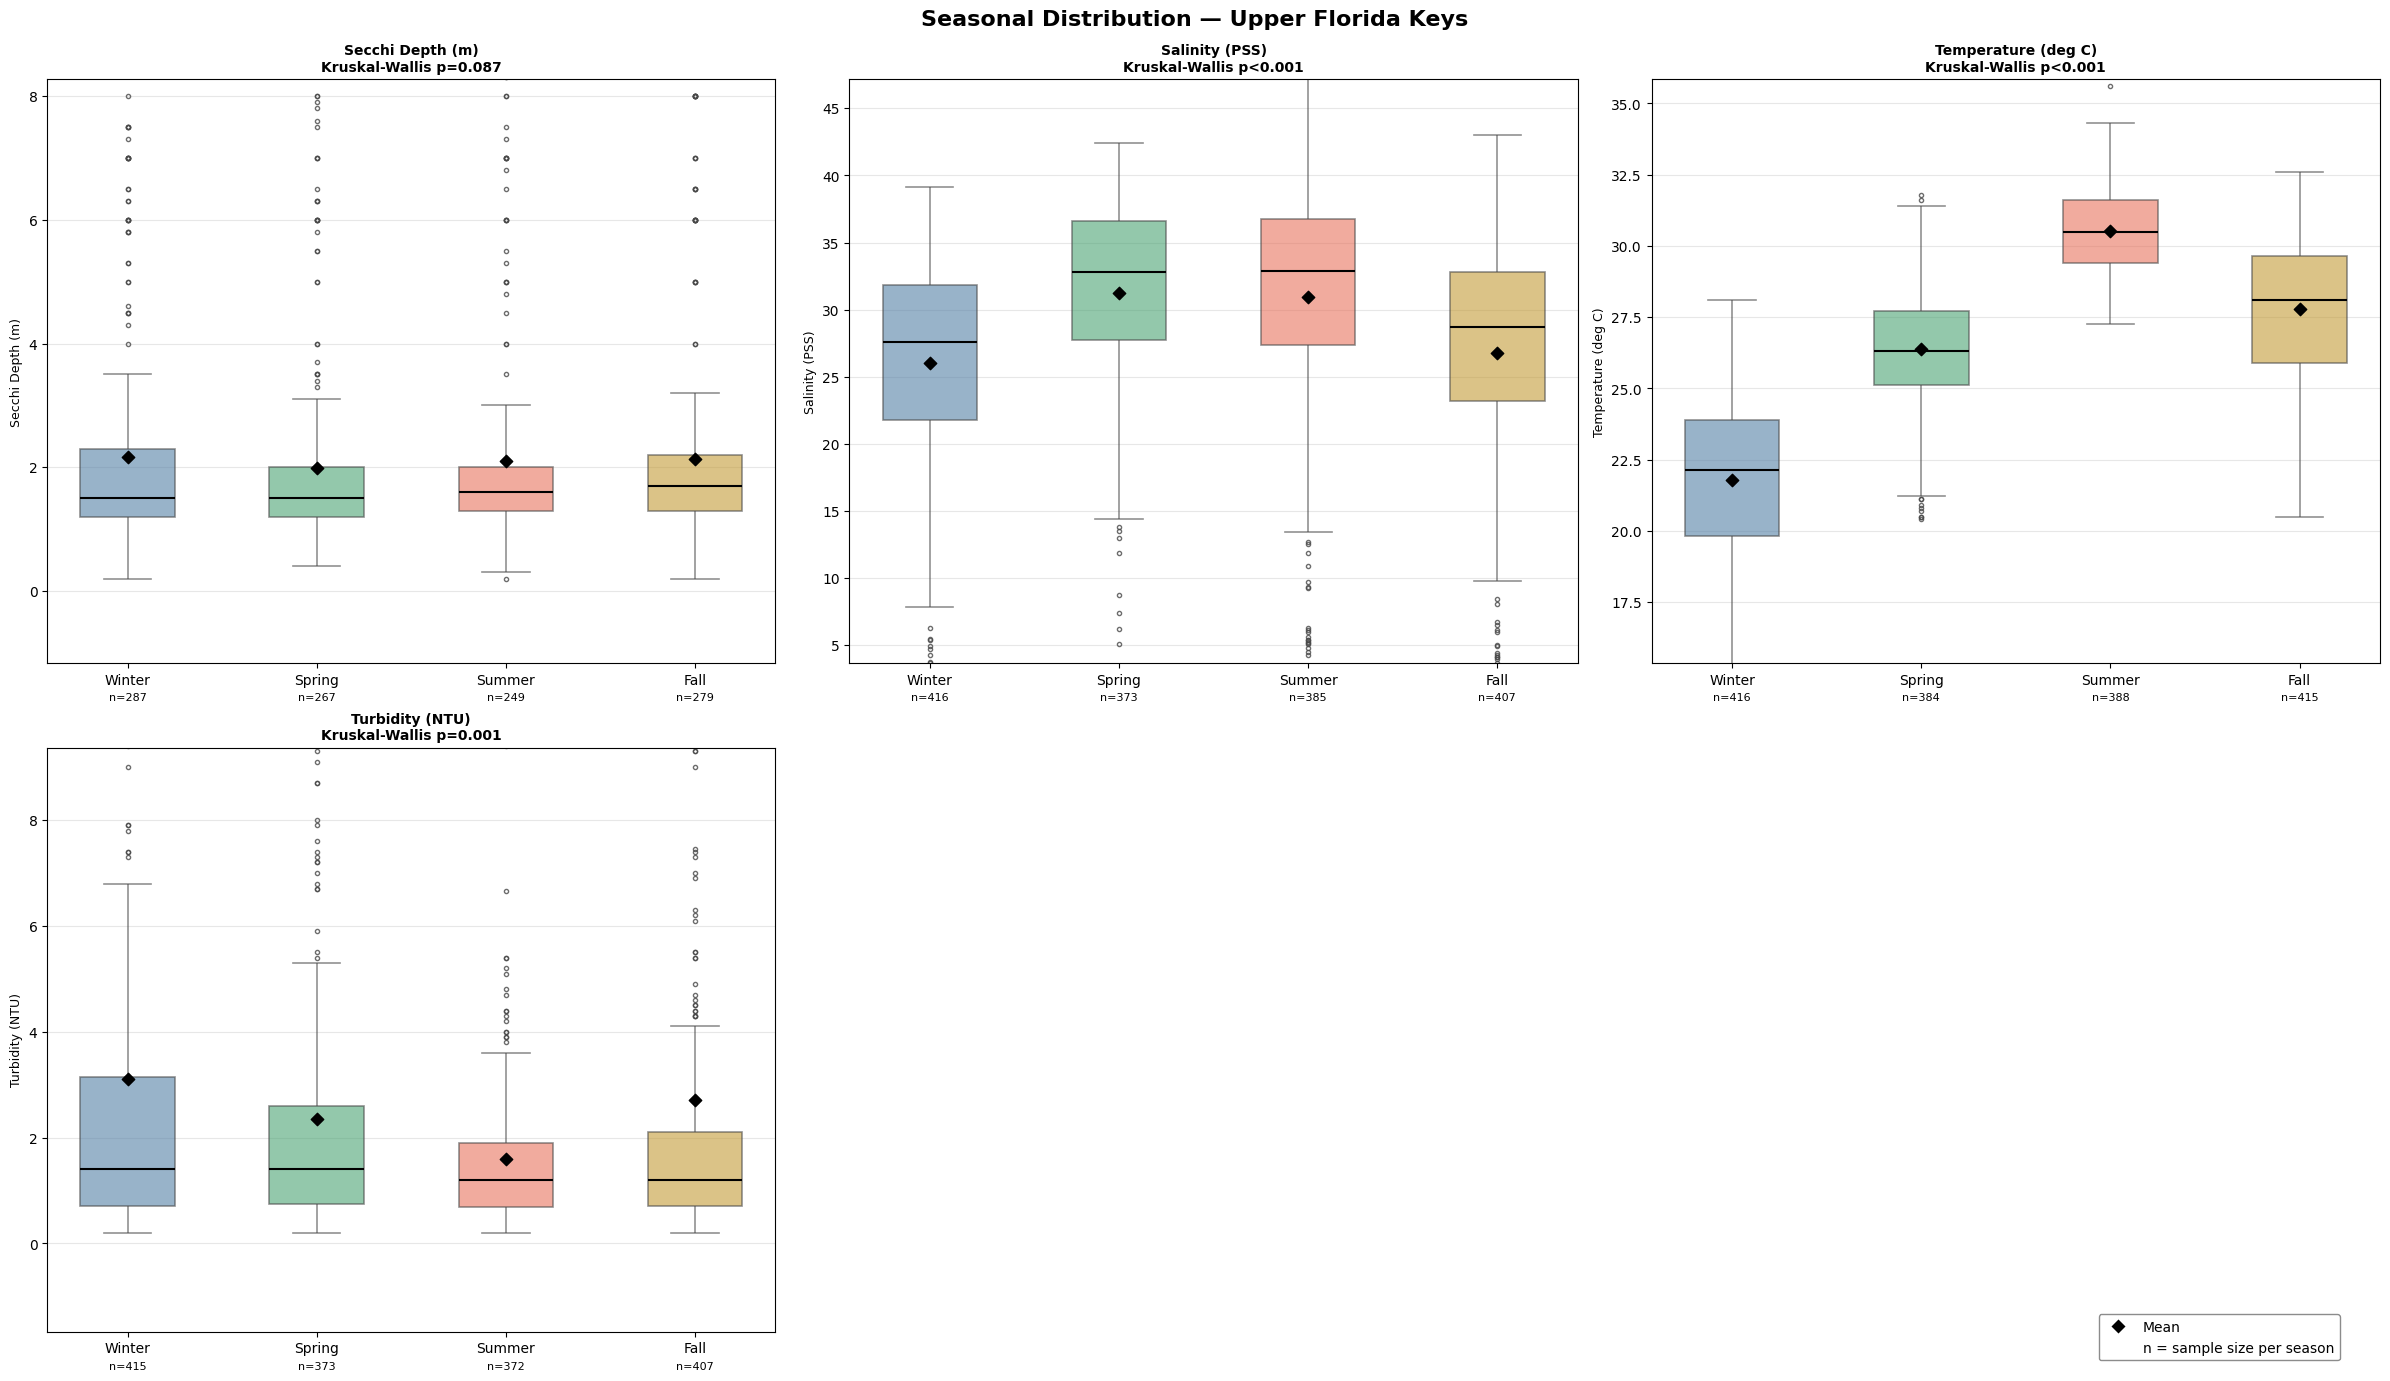

In [54]:
# Seasonal Boxplots (one per parameter)
wq_plot = wq_gdf.reset_index().copy()
wq_plot["Month"] = pd.to_datetime(wq_plot["Date"]).dt.month
wq_plot["Season"] = wq_plot["Month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",   10: "Fall",  11: "Fall"
})

season_order = ["Winter", "Spring", "Summer", "Fall"]
season_palette = {
    "Winter": "steelblue",
    "Spring": "mediumseagreen",
    "Summer": "tomato",
    "Fall":   "goldenrod"
}

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for i, col in enumerate(param_cols):
    ax = axes[i]

    # Boxplot
    sns.boxplot(data=wq_plot, x="Season", y=col, hue="Season",
                order=season_order, palette=season_palette,
                legend=False, ax=ax, width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markersize=3, alpha=0.8),
                boxprops=dict(alpha=0.6),
                whiskerprops=dict(alpha=0.6),
                capprops=dict(alpha=0.6),
                medianprops=dict(color='black', linewidth=1.5))
    
    # Auto zoom y axis with padding around the data range
    col_data = wq_plot[col].dropna()
    q1 = col_data.quantile(0.05)
    q3 = col_data.quantile(0.95)
    padding = (q3 - q1) * 0.3
    ax.set_ylim(q1 - padding, q3 + padding)

    # Add mean marker
    means = wq_plot.groupby("Season")[col].mean()
    for j, season in enumerate(season_order):
        if season in means:
            ax.scatter(j, means[season], marker='D', color='black',
                      s=40, zorder=5, label='Mean' if j == 0 else "")

    # Add sample size per season
    for j, season in enumerate(season_order):
        n = wq_plot[wq_plot["Season"] == season][col].dropna().shape[0]
        ax.text(j, -0.05, f'n={n}',
                ha='center', va='top', fontsize=8, color='black',
                transform=ax.get_xaxis_transform())

    # Add significance brackets between Winter and Summer
    groups = [wq_plot[wq_plot["Season"] == s][col].dropna() for s in season_order]
    _, p_val = stats.kruskal(*[g for g in groups if len(g) > 0])
    p_str = "p<0.001" if p_val < 0.001 else f"p={p_val:.3f}"
    ax.set_title(f"{col}\nKruskal-Wallis {p_str}", fontsize=10, fontweight="bold")

    ax.set_xlabel("")
    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Seasonal Distribution — Upper Florida Keys", fontsize=16, fontweight="bold")

# Build shared legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='D', color='w', markerfacecolor='black',
           markersize=8, label='Mean'),
    Line2D([0], [0], color='none', label='n = sample size per season')
]

fig.legend(handles=legend_elements, loc='lower right',
           bbox_to_anchor=(0.98, 0.01), fontsize=10,
           frameon=True, framealpha=0.9, edgecolor='gray')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("seasonal_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

### Monthly Mean Time Series 

Blue banding shows standard deviation. \
Narrow band — readings were consistent that month across stations and time, conditions were stable \
Wide band — high variability, meaning either different stations had very different readings, or conditions fluctuated a lot within the month

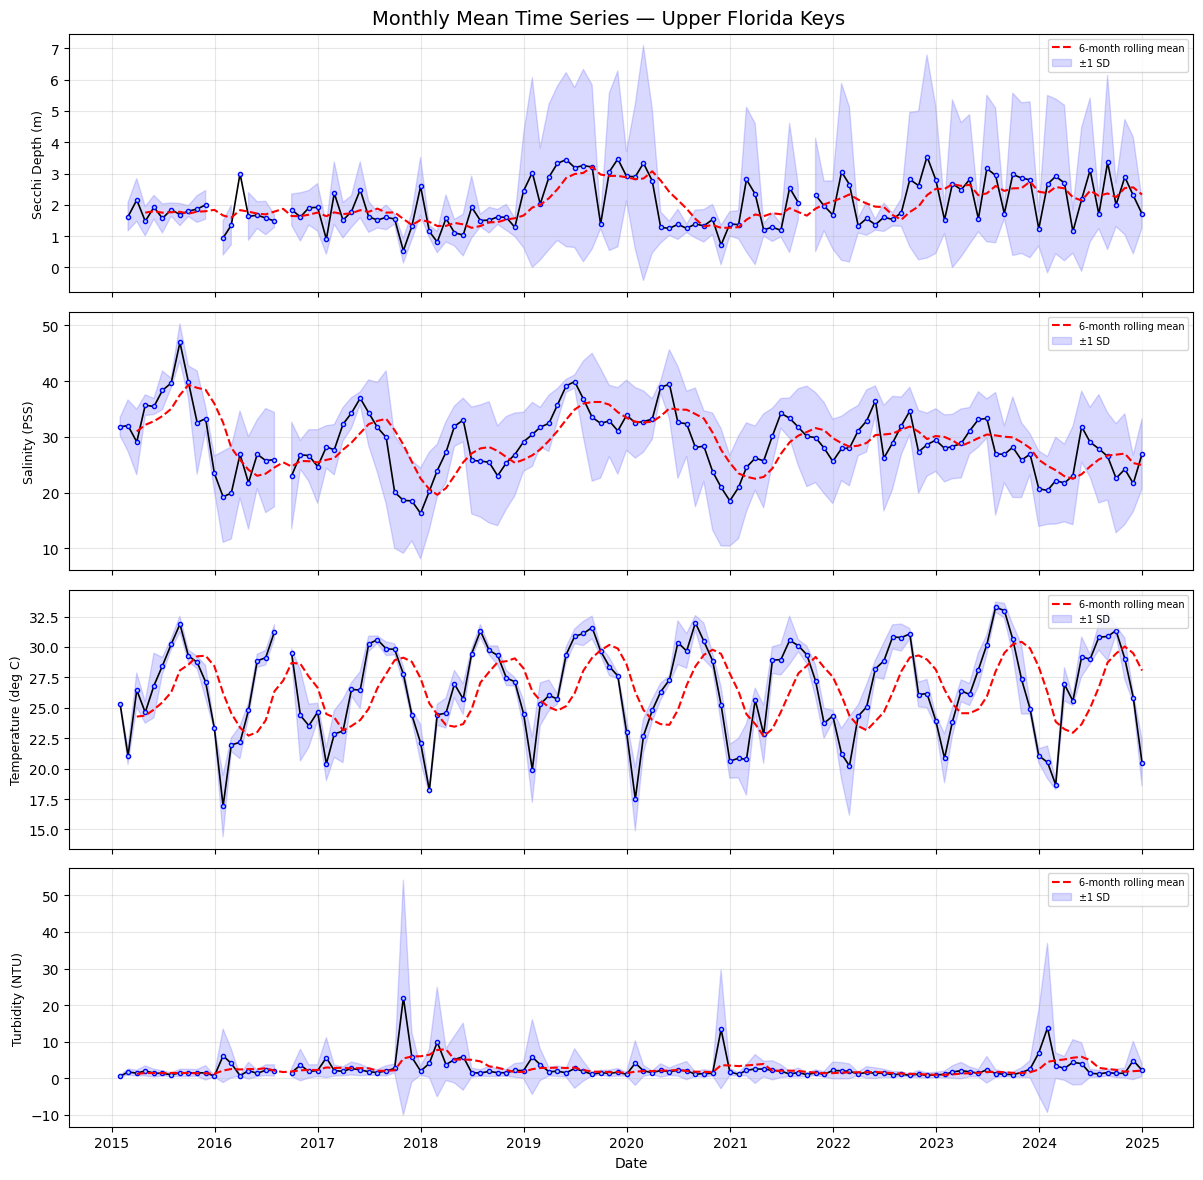

In [ ]:
# Time Series (monthly mean per parameter)
fig, axes = plt.subplots(len(param_cols), 1, figsize=(12, 3 * len(param_cols)), sharex=True)

for i, col in enumerate(param_cols):
    # Compute mean and std from the same resampling operation
    monthly_mean = wq_gdf[col].resample("ME").mean()
    monthly_std  = wq_gdf[col].resample("ME").std()

    axes[i].plot(monthly_mean.index, monthly_mean, linewidth=1.2, 
                 color='black', marker='o', markersize=3, markerfacecolor='lightblue',
                 markeredgecolor='blue')
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].grid(True, alpha=0.3)
    
    # Add a rolling 6-month mean to show trend
    rolling = monthly_mean.rolling(window=6, min_periods=3).mean()
    axes[i].plot(monthly_mean.index, rolling, linewidth=1.5, 
                 color='red', linestyle='--', label='6-month rolling mean')
    
    # Shade ± 1 standard deviation band
    axes[i].fill_between(monthly_mean.index, 
                          monthly_mean - monthly_std, 
                          monthly_mean + monthly_std,
                          alpha=0.15, color='blue', label='±1 SD')
    
    axes[i].legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel("Date")
fig.suptitle("Monthly Mean Time Series — Upper Florida Keys", fontsize=14)
plt.tight_layout()
plt.savefig("time_series.png", dpi=150)
plt.show()

### Relationship between parameters

Visualization of the relationship between parameters, organized seasonaly. 

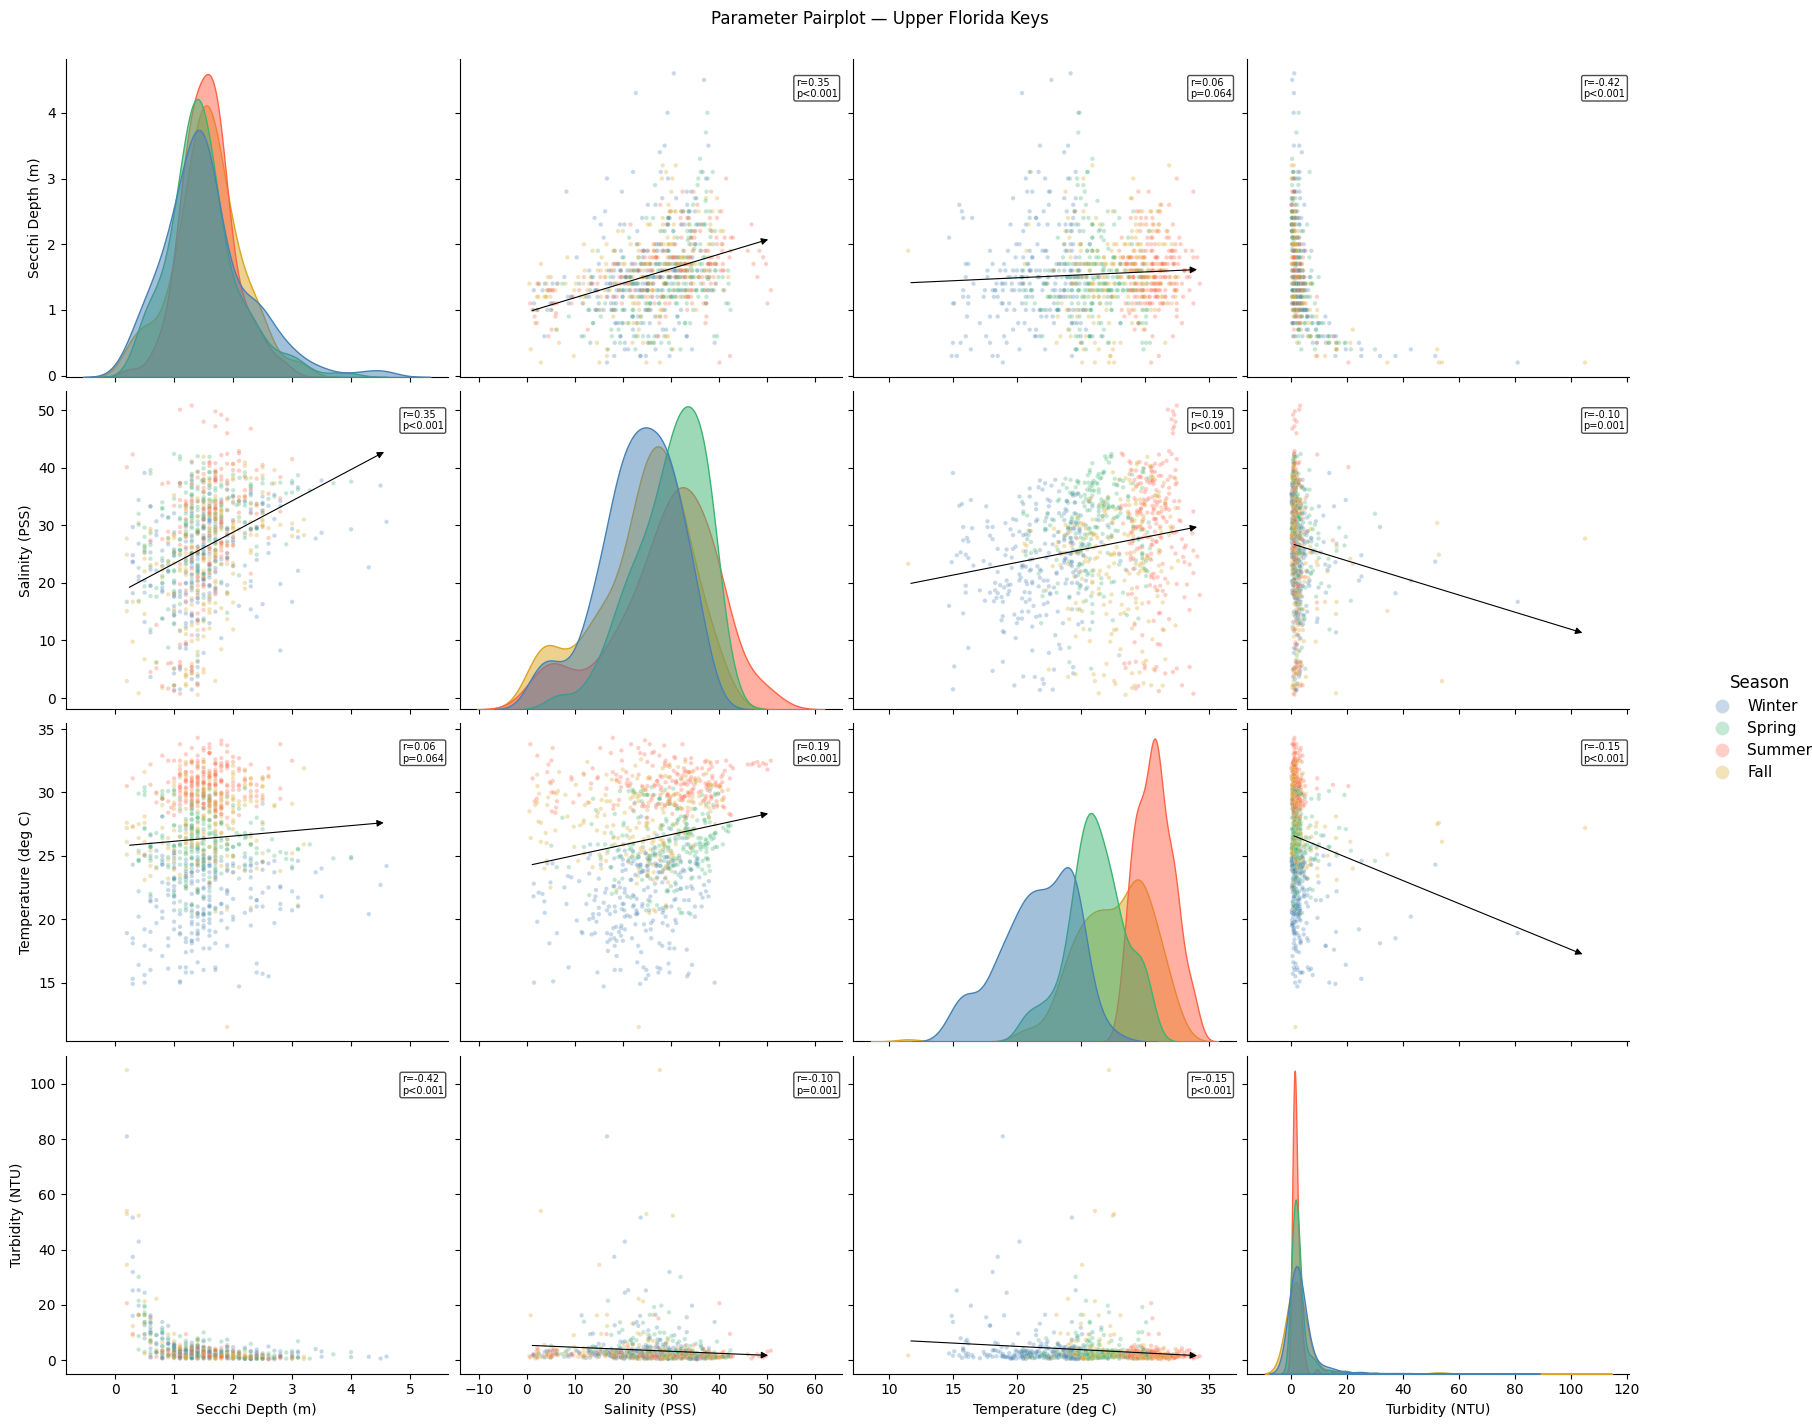

In [126]:
# Pairplot (relationships between all parameters)
pair_data = wq_gdf[param_cols].dropna().reset_index(drop=True)

# Add season for color coding
pair_data["Season"] = pd.to_datetime(wq_gdf[param_cols].dropna().index).month.map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",   10: "Fall",  11: "Fall"
})

season_palette = {
    "Winter": "steelblue",
    "Spring": "mediumseagreen",
    "Summer": "tomato",
    "Fall":   "goldenrod"
}

# Pairplot colored by season
g = sns.pairplot(pair_data, hue="Season", palette=season_palette,
                 diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10},
                 diag_kws={"alpha": 0.5},
                 height=3.5, aspect=1.2)

# Add correlation coefficients and regression lines to off-diagonal plots
for i, row_col in enumerate(param_cols):
    for j, col_col in enumerate(param_cols):
        if i == j:
            continue
        ax = g.axes[i, j]

        # Get clean paired data for these two columns
        paired = pair_data[[row_col, col_col]].dropna()
        if len(paired) < 5:
            continue

        x = paired[col_col]
        y = paired[row_col]

        # Regression line with arrow
        slope, intercept, r, p, _ = stats.linregress(x, y)
        x_start = x.min()
        x_end   = x.max()
        y_start = slope * x_start + intercept
        y_end   = slope * x_end   + intercept

        ax.annotate("",
                    xy=(x_end, y_end),
                    xytext=(x_start, y_start),
                    arrowprops=dict(
                        arrowstyle="-|>",
                        color="black",
                        lw=0.8,
                    ))

        # Correlation coefficient and p-value
        p_str = "p<0.001" if p < 0.001 else f"p={p:.3f}"
        ax.annotate(f"r={r:.2f}\n{p_str}",
                    xy=(0.88, 0.88), xycoords='axes fraction',
                    fontsize=7, color='black',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Move and resize legend
g._legend.set_bbox_to_anchor((1.02, 0.5))
g._legend.set_title("Season")
for text in g._legend.get_texts():
    text.set_fontsize(11)
g._legend.get_title().set_fontsize(12)
for handle in g._legend.legend_handles:
    handle.set_markersize(10)

g.fig.suptitle("Parameter Pairplot — Upper Florida Keys", y=1.02)
plt.savefig("pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Spatial Visualization of Parameters

A visual display of the mean value for each parameter per station. \
Includes overlayed map of study area and exact shapefile. 

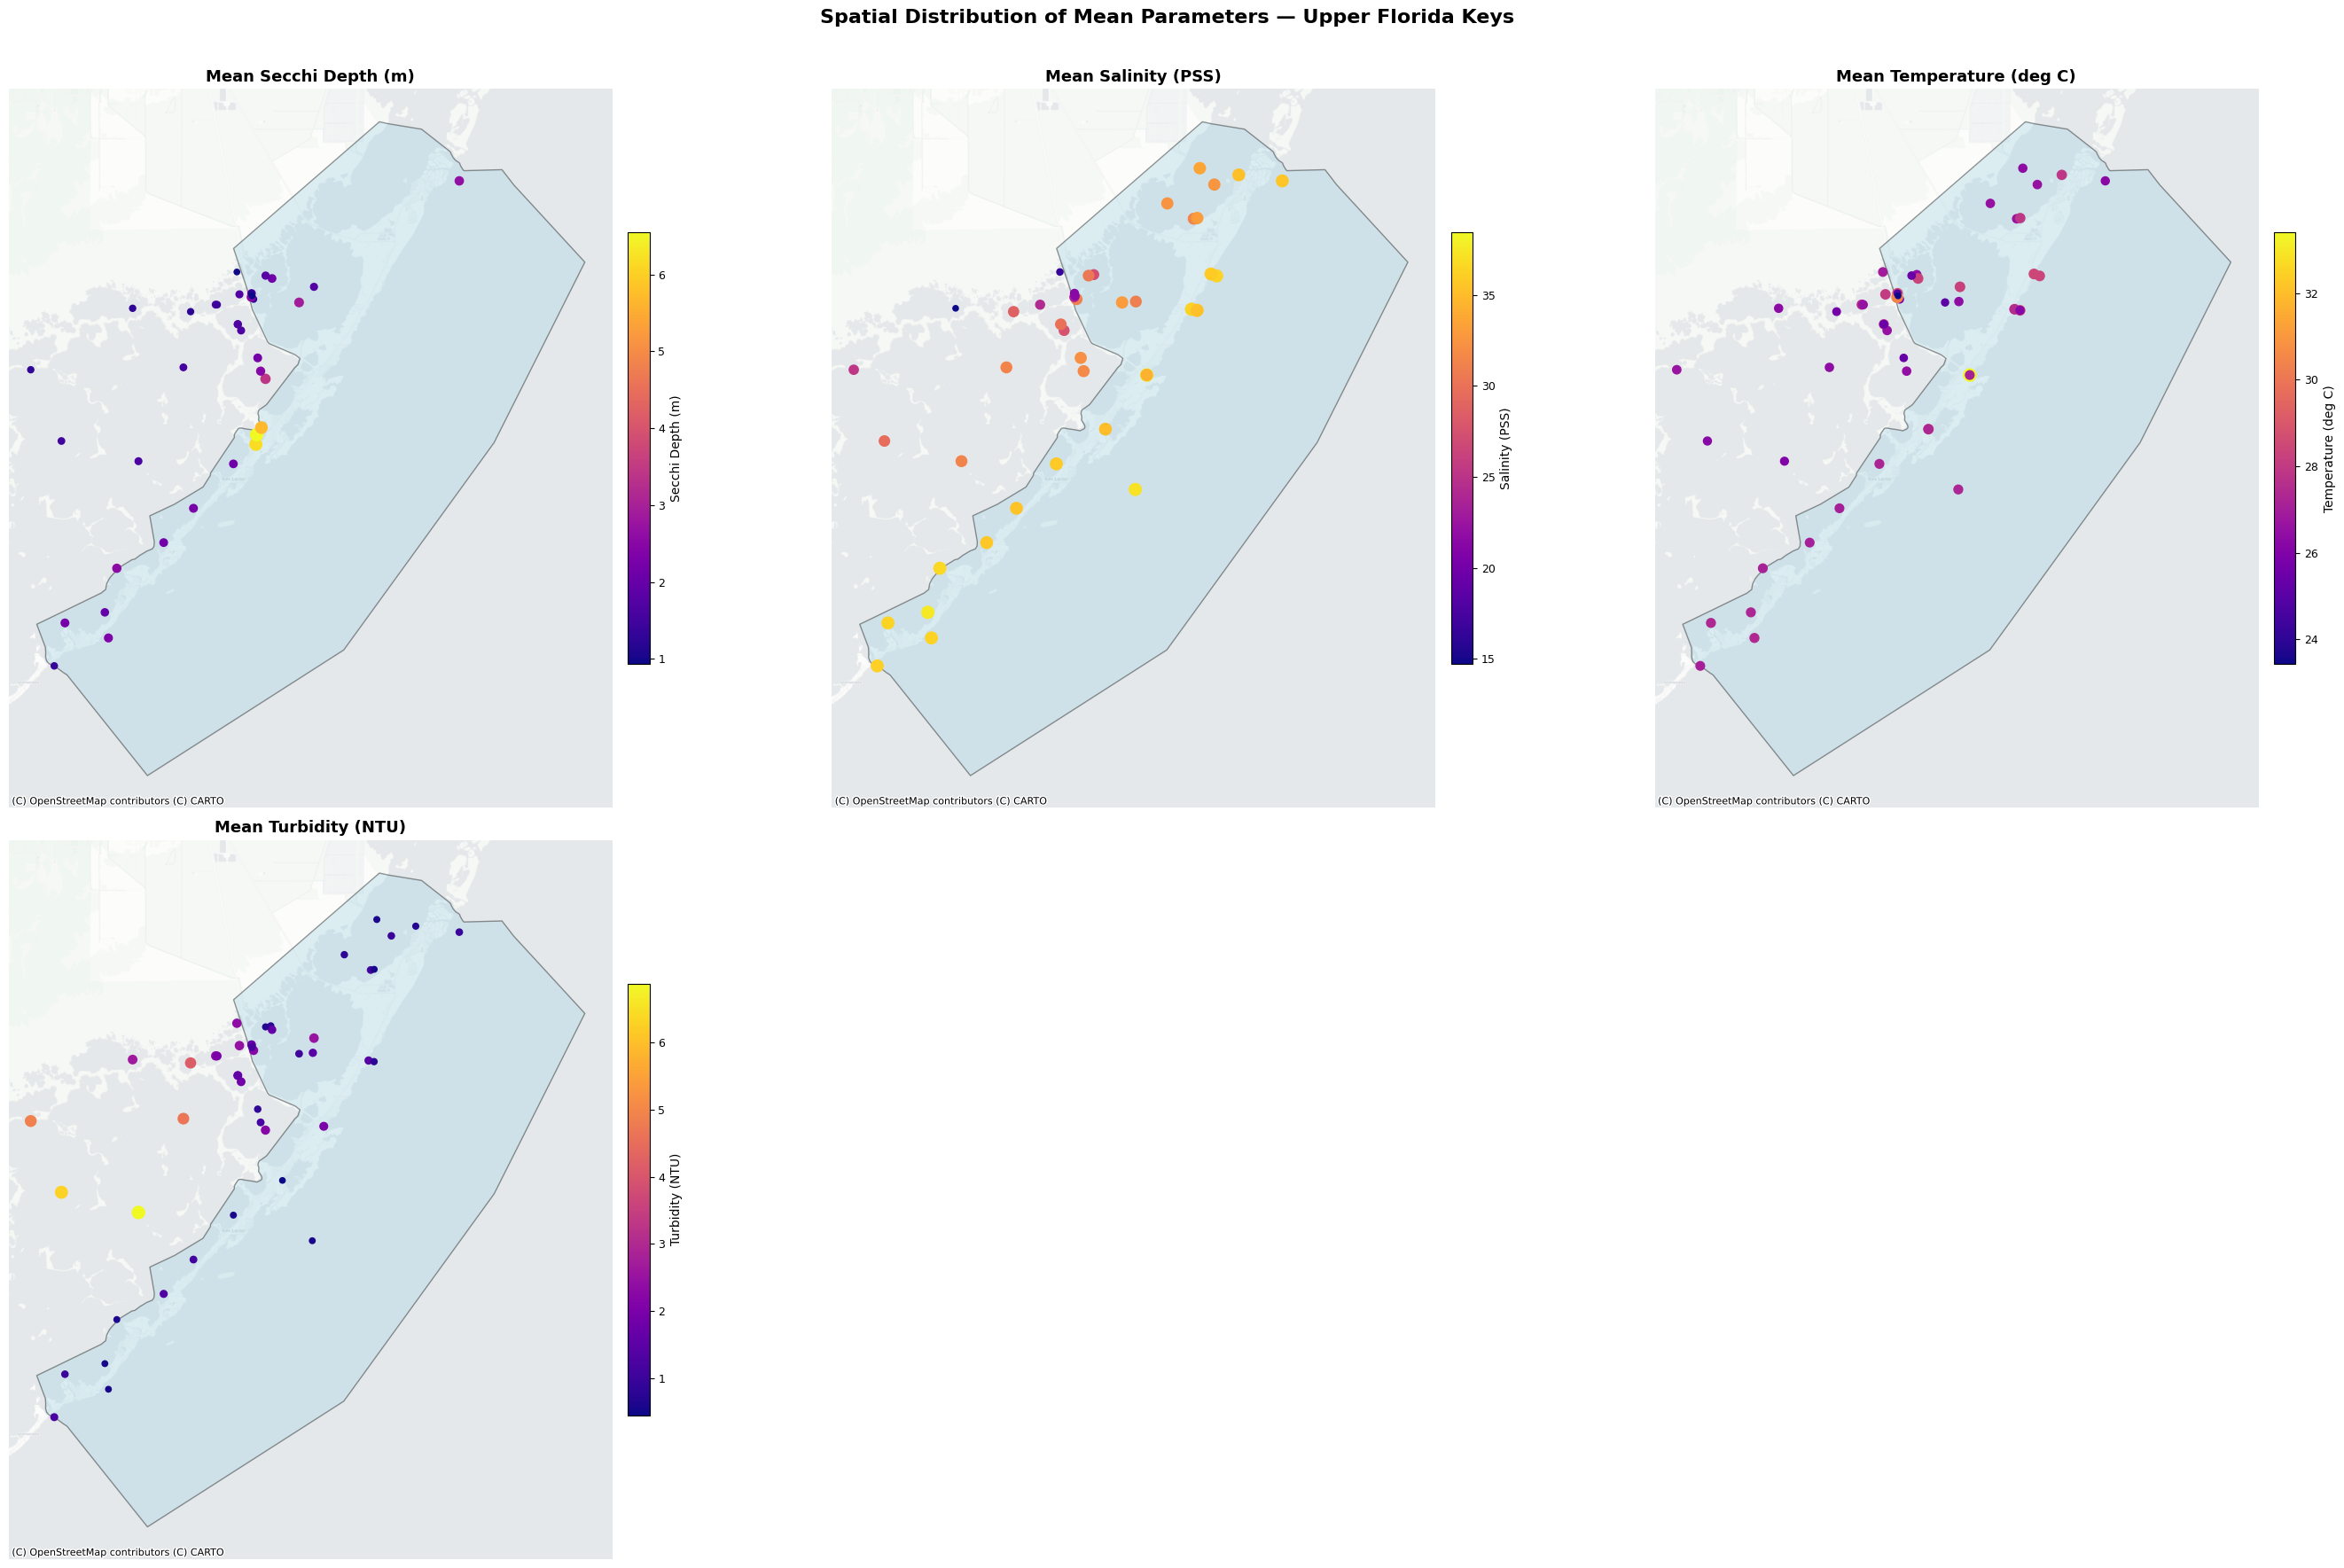

In [127]:
station_means = wq_gdf.groupby("MonitoringLocationIdentifier")[param_cols].mean()
wq_stations = wq_gdf.dissolve(by="MonitoringLocationIdentifier")[["geometry"]].join(station_means)

# Reproject to Web Mercator for basemap compatibility
reef_wm     = reef_shape.to_crs(epsg=3857)
stations_wm = wq_stations.to_crs(epsg=3857)

fig, axes = plt.subplots(2, 3, figsize=(28, 18))
axes = axes.flatten()

for i, col in enumerate(param_cols):
    ax = axes[i]

    # Plot shapefile FIRST to set axes extent
    reef_wm.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.4, zorder=1)

    # Add basemap using explicit CRS
    try:
        ctx.add_basemap(ax, crs=stations_wm.crs,
                        source=ctx.providers.CartoDB.Positron,
                        alpha=0.6, zorder=0, zoom=12)
    except Exception as e:
        print(f"Basemap error: {e}")
        pass

    # Scale marker size to value
    values = stations_wm[col].dropna()
    scaled_sizes = ((values - values.min()) / (values.max() - values.min()) * 80) + 20

    # Plot stations
    stations_wm.dropna(subset=[col]).plot(
        ax=ax, column=col, cmap="plasma",
        markersize=scaled_sizes,
        legend=False,
        zorder=3
    )

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap="plasma",
                                norm=plt.Normalize(vmin=values.min(), vmax=values.max()))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label(col, fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    ax.set_title(f"Mean {col}", fontsize=13, fontweight="bold")
    ax.axis("off")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Spatial Distribution of Mean Parameters — Upper Florida Keys",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("spatial_means.png", dpi=150, bbox_inches="tight")
plt.show()

### Read / load Indices Summary 

In [64]:
df_indices = pd.read_csv("indices_summary.csv")
print(df_indices.columns.tolist())
print(df_indices.head(2))

['tile_id', 'time', 'NDVI', 'NDWI', 'NDAVI', 'EVI', 'SSSII', 'NDTI', 'DII']
  tile_id                 time      NDVI      NDWI     NDAVI  EVI     SSSII  \
0  T17RNH  2015-11-13 16:00:52 -0.028805  0.153598 -0.226168  NaN  0.127616   
1  T17RNH  2016-03-02 15:54:02 -0.037907  0.181355 -0.248123  inf  0.147029   

       NDTI       DII  
0 -0.127616 -0.153930  
1 -0.147029 -0.142977  


In [69]:
# Load spectral indices summary
df_indices = pd.read_csv("indices_summary.csv", parse_dates=["time"])
df_indices = df_indices.set_index("time").sort_index()

print(f"Shape: {df_indices.shape}")
print(f"Date range: {df_indices.index.min()} to {df_indices.index.max()}")
print(f"\nColumns: {df_indices.columns.tolist()}")
print(f"\nNaN counts:\n{df_indices.isnull().sum()}")
display(df_indices.head())

Shape: (145, 8)
Date range: 2015-11-13 16:00:52 to 2024-12-05 16:05:11

Columns: ['tile_id', 'NDVI', 'NDWI', 'NDAVI', 'EVI', 'SSSII', 'NDTI', 'DII']

NaN counts:
tile_id      0
NDVI         1
NDWI         1
NDAVI        1
EVI        143
SSSII        0
NDTI         0
DII         92
dtype: int64


,tile_id,NDVI,NDWI,NDAVI,EVI,SSSII,NDTI,DII
time,,,,,,,,
2015-11-13 16:00:52,T17RNH,-0.028805,0.153598,-0.226168,NaN,0.127616,-0.127616,-0.153930
2015-11-13 16:00:52,T17RNJ,0.001099,0.111727,-0.171458,NaN,0.115901,-0.115901,-0.126511
2016-03-02 15:54:02,T17RNH,-0.037907,0.181355,-0.248123,inf,0.147029,-0.147029,-0.142977
2016-05-21 16:05:22,T17RNJ,-0.004456,0.082916,-0.119983,NaN,0.080308,-0.080308,-0.076728
2016-06-30 16:05:12,T17RNJ,-0.003134,0.075496,-0.109929,NaN,0.074221,-0.074221,-0.070902


In [71]:
print(wq_reset.columns.tolist())
print(idx_reset.columns.tolist())

['ActivityStartDate', 'MonitoringLocationIdentifier', 'Secchi Depth (m)', 'Salinity (PSS)', 'Temperature (deg C)', 'Turbidity (NTU)']
['date', 'NDVI', 'NDWI', 'NDAVI', 'SSSII', 'NDTI', 'DII']


### Making spectral data useable with in-situ data

EVI must be dropped due to mostly NaN values. This is not unexpected as EVI (Enhanced Vegetation Index) \
was designed for desne terrestrial vegetetation. 

Because Sentinel-2 works on a 5 day revisit interval and data from monitoring stations is not measured \
in fixed time intervals, a tolerance period (3 days) must be allowed to match Sentinel-2 overpass days with temporaly \
nearby water quality measuerments. 

In [80]:
df_indices = pd.read_csv("indices_summary.csv", parse_dates=["time"])
df_indices = df_indices.set_index("time").sort_index()

# Drop EVI — 143/145 NaN, not usable
df_indices = df_indices.drop(columns=["EVI"])

# Average the two tiles per date to get one value per day
index_cols = ["NDVI", "NDWI", "NDAVI", "SSSII", "NDTI", "DII"]
idx_daily = df_indices.groupby(df_indices.index.date)[index_cols].mean()
idx_daily.index = pd.to_datetime(idx_daily.index)
idx_daily.index.name = "date"

print(f"Shape after averaging tiles: {idx_daily.shape}")
print(f"Date range: {idx_daily.index.min()} to {idx_daily.index.max()}")
display(idx_daily.head())

# Merge with WQ data
from pandas import merge_asof

# Ensure both are sorted by date
wq_sorted  = wq_reset.sort_values("ActivityStartDate")
idx_sorted = idx_reset.sort_values("date")

# Merge within 3 day tolerance
df_combined = merge_asof(
    wq_sorted,
    idx_sorted,
    left_on="ActivityStartDate",
    right_on="date",
    tolerance=pd.Timedelta("3 days"),
    direction="nearest"
)

df_combined = df_combined.drop(columns=["date"]).set_index("ActivityStartDate").sort_index()
df_combined.index.name = "Date"

matched = df_combined["NDVI"].notna().sum()
total   = len(df_combined)
print(f"Total WQ rows: {total}")
print(f"Rows with spectral match: {matched} ({matched/total:.0%})")
display(df_combined.head())

Shape after averaging tiles: (101, 6)
Date range: 2015-11-13 00:00:00 to 2024-12-05 00:00:00


,NDVI,NDWI,NDAVI,SSSII,NDTI,DII
date,,,,,,
2015-11-13,-0.013853,0.132663,-0.198813,0.121758,-0.121758,-0.140220
2016-03-02,-0.037907,0.181355,-0.248123,0.147029,-0.147029,-0.142977
2016-05-21,-0.004456,0.082916,-0.119983,0.080308,-0.080308,-0.076728
2016-06-30,-0.011163,0.077989,-0.116710,0.068367,-0.068367,-0.079466
2016-07-20,-0.011372,0.089530,-0.134938,0.080036,-0.080036,-0.093898


Total WQ rows: 1749
Rows with spectral match: 387 (22%)


,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU),NDVI,NDWI,NDAVI,SSSII,NDTI,DII
Date,,,,,,,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,21FLDADE_WQX-BB51,NaN,30.806667,25.396667,0.4,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-03,21FLSFWM_WQX-6598,2.5,35.000000,21.000000,1.8,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-03,21FLSFWM_WQX-6599,1.6,32.800000,21.500000,2.2,NaN,NaN,NaN,NaN,NaN,NaN


#### 387 matched readings (22%) across a 10 year span with a 3 days tolerance period. This is reasonable for correlation analysis. 

In [128]:
wq_cols       = ["Secchi Depth (m)", "Salinity (PSS)", 
                  "Temperature (deg C)", "Turbidity (NTU)"]
spectral_cols = ["NDVI", "NDWI", "NDAVI", "SSSII", "NDTI", "DII"]

# Dataset 1 — Full WQ time series (monthly mean across stations)
df_wq_monthly = df_pivot.copy()
df_wq_monthly["YearMonth"] = df_pivot.index.to_period("M")
df_wq_monthly = df_wq_monthly.groupby("YearMonth")[wq_cols].mean()
df_wq_monthly.index = df_wq_monthly.index.to_timestamp()
df_wq_monthly.index.name = "Date"

print(f"WQ monthly shape: {df_wq_monthly.shape}")
print(f"Date range: {df_wq_monthly.index.min()} to {df_wq_monthly.index.max()}")

# Dataset 2 — Full spectral index time series (monthly mean across tiles)
df_spec_monthly = idx_daily.copy()
df_spec_monthly["YearMonth"] = idx_daily.index.to_period("M")
df_spec_monthly = df_spec_monthly.groupby("YearMonth")[spectral_cols].mean()
df_spec_monthly.index = df_spec_monthly.index.to_timestamp()
df_spec_monthly.index.name = "Date"

print(f"\nSpectral monthly shape: {df_spec_monthly.shape}")
print(f"Date range: {df_spec_monthly.index.min()} to {df_spec_monthly.index.max()}")

# Dataset 3 — Matched pairs for correlation (387 rows)
df_matched = df_combined.dropna(subset=["NDVI"])[wq_cols + spectral_cols].copy()

print(f"\nMatched pairs shape: {df_matched.shape}")
print(f"Date range: {df_matched.index.min()} to {df_matched.index.max()}")

WQ monthly shape: (119, 4)
Date range: 2015-01-01 00:00:00 to 2024-12-01 00:00:00

Spectral monthly shape: (83, 6)
Date range: 2015-11-01 00:00:00 to 2024-12-01 00:00:00

Matched pairs shape: (387, 10)
Date range: 2016-05-23 00:00:00 to 2024-12-05 00:00:00


### Mann-Kendall Test

Used to detect whether a time series exhibits a consistent upward or downward trend over time. \
Evaluates the direction and strength of the trend using Kendall’s tau (τ) and determines its statistical significance with a p-value.


In [85]:
# SECTION 1 — Mann-Kendall Trend Analysis: Water Quality

mk_wq_results = []

for col in wq_cols:
    series = df_wq_monthly[col].dropna()
    if len(series) < 10:
        print(f"SKIP {col} — not enough data")
        continue
    result = mk_test(series)
    mk_wq_results.append({
        "Parameter":   col,
        "Trend":       result.trend,
        "p-value":     round(result.p, 4),
        "Tau":         round(result.Tau, 4),
        "Sen Slope":   round(result.slope, 6),
        "Significant": result.p < 0.05
    })

df_mk_wq = pd.DataFrame(mk_wq_results)
print("=== Water Quality Trends ===")
print(df_mk_wq.to_string(index=False))

=== Water Quality Trends ===
          Parameter      Trend  p-value     Tau  Sen Slope  Significant
   Secchi Depth (m) increasing   0.0095  0.1631   0.005800         True
     Salinity (PSS)   no trend   0.0858 -0.1067  -0.030270        False
Temperature (deg C)   no trend   0.3417  0.0591   0.010013        False
    Turbidity (NTU)   no trend   0.3417 -0.0591  -0.002099        False


In [86]:
# SECTION 2 — Mann-Kendall Trend Analysis: Spectral Indices
mk_spec_results = []

for col in spectral_cols:
    series = df_spec_monthly[col].dropna()
    if len(series) < 10:
        print(f"SKIP {col} — not enough data")
        continue
    result = mk_test(series)
    mk_spec_results.append({
        "Index":       col,
        "Trend":       result.trend,
        "p-value":     round(result.p, 4),
        "Tau":         round(result.Tau, 4),
        "Sen Slope":   round(result.slope, 6),
        "Significant": result.p < 0.05
    })

df_mk_spec = pd.DataFrame(mk_spec_results)
print("=== Spectral Index Trends ===")
print(df_mk_spec.to_string(index=False))

=== Spectral Index Trends ===
Index      Trend  p-value     Tau  Sen Slope  Significant
 NDVI increasing   0.0409  0.1531   0.000192         True
 NDWI   no trend   0.0623 -0.1396  -0.000242        False
NDAVI increasing   0.0305  0.1619   0.000428         True
SSSII   no trend   0.7891 -0.0203  -0.000030        False
 NDTI   no trend   0.7891  0.0203   0.000030        False
  DII   no trend   0.1517  0.1517   0.002610        False


c:\Users\ianra\miniconda3\Lib\site-packages\pymannkendall\pymannkendall.py:155: RuntimeWarning: invalid value encountered in subtract
  d[idx : idx + len(j)] = (x[j] - x[i]) / (j - i)


### Correlation Analysis:

Pearson correlation (r): measures the strength and direction of  alinear relationship between values. Assumes normal distribution. \
Spearman correlation (p, rho): measures the strength and direction of a monotomic relationship based on ranked data. DOES NOT assume normal distribution. \

In [87]:
# SECTION 3 — Correlation Analysis: Matched Pairs

# Define the most ecologically meaningful pairs to test
pair_cols = [
    ("Turbidity (NTU)",   "NDTI",  "Turbidity vs NDTI"),
    ("Turbidity (NTU)",   "NDWI",  "Turbidity vs NDWI"),
    ("Secchi Depth (m)",  "NDWI",  "Secchi Depth vs NDWI"),
    ("Secchi Depth (m)",  "NDVI",  "Secchi Depth vs NDVI"),
    ("Secchi Depth (m)",  "NDAVI", "Secchi Depth vs NDAVI"),
    ("Salinity (PSS)",    "NDAVI", "Salinity vs NDAVI"),
]

corr_results = []

for wq_col, spec_col, label in pair_cols:
    paired = df_matched[[wq_col, spec_col]].dropna()
    if len(paired) < 10:
        print(f"SKIP {label} — not enough pairs")
        continue

    r, p = stats.pearsonr(paired[wq_col], paired[spec_col])
    rho, p_sp = stats.spearmanr(paired[wq_col], paired[spec_col])

    corr_results.append({
        "Pair":           label,
        "n":              len(paired),
        "Pearson r":      round(r, 3),
        "Pearson p":      round(p, 4),
        "Spearman rho":   round(rho, 3),
        "Spearman p":     round(p_sp, 4),
        "Significant":    p < 0.05
    })

df_corr = pd.DataFrame(corr_results)
print("=== WQ — Spectral Correlations ===")
print(df_corr.to_string(index=False))

=== WQ — Spectral Correlations ===
                 Pair   n  Pearson r  Pearson p  Spearman rho  Spearman p  Significant
    Turbidity vs NDTI 359     -0.133     0.0119        -0.129      0.0141         True
    Turbidity vs NDWI 359      0.325     0.0000         0.155      0.0032         True
 Secchi Depth vs NDWI 244     -0.205     0.0013        -0.186      0.0036         True
 Secchi Depth vs NDVI 244      0.091     0.1587        -0.015      0.8171        False
Secchi Depth vs NDAVI 244      0.176     0.0059         0.108      0.0930         True
    Salinity vs NDAVI 366      0.087     0.0964         0.061      0.2451        False


### Correlation Visualization 

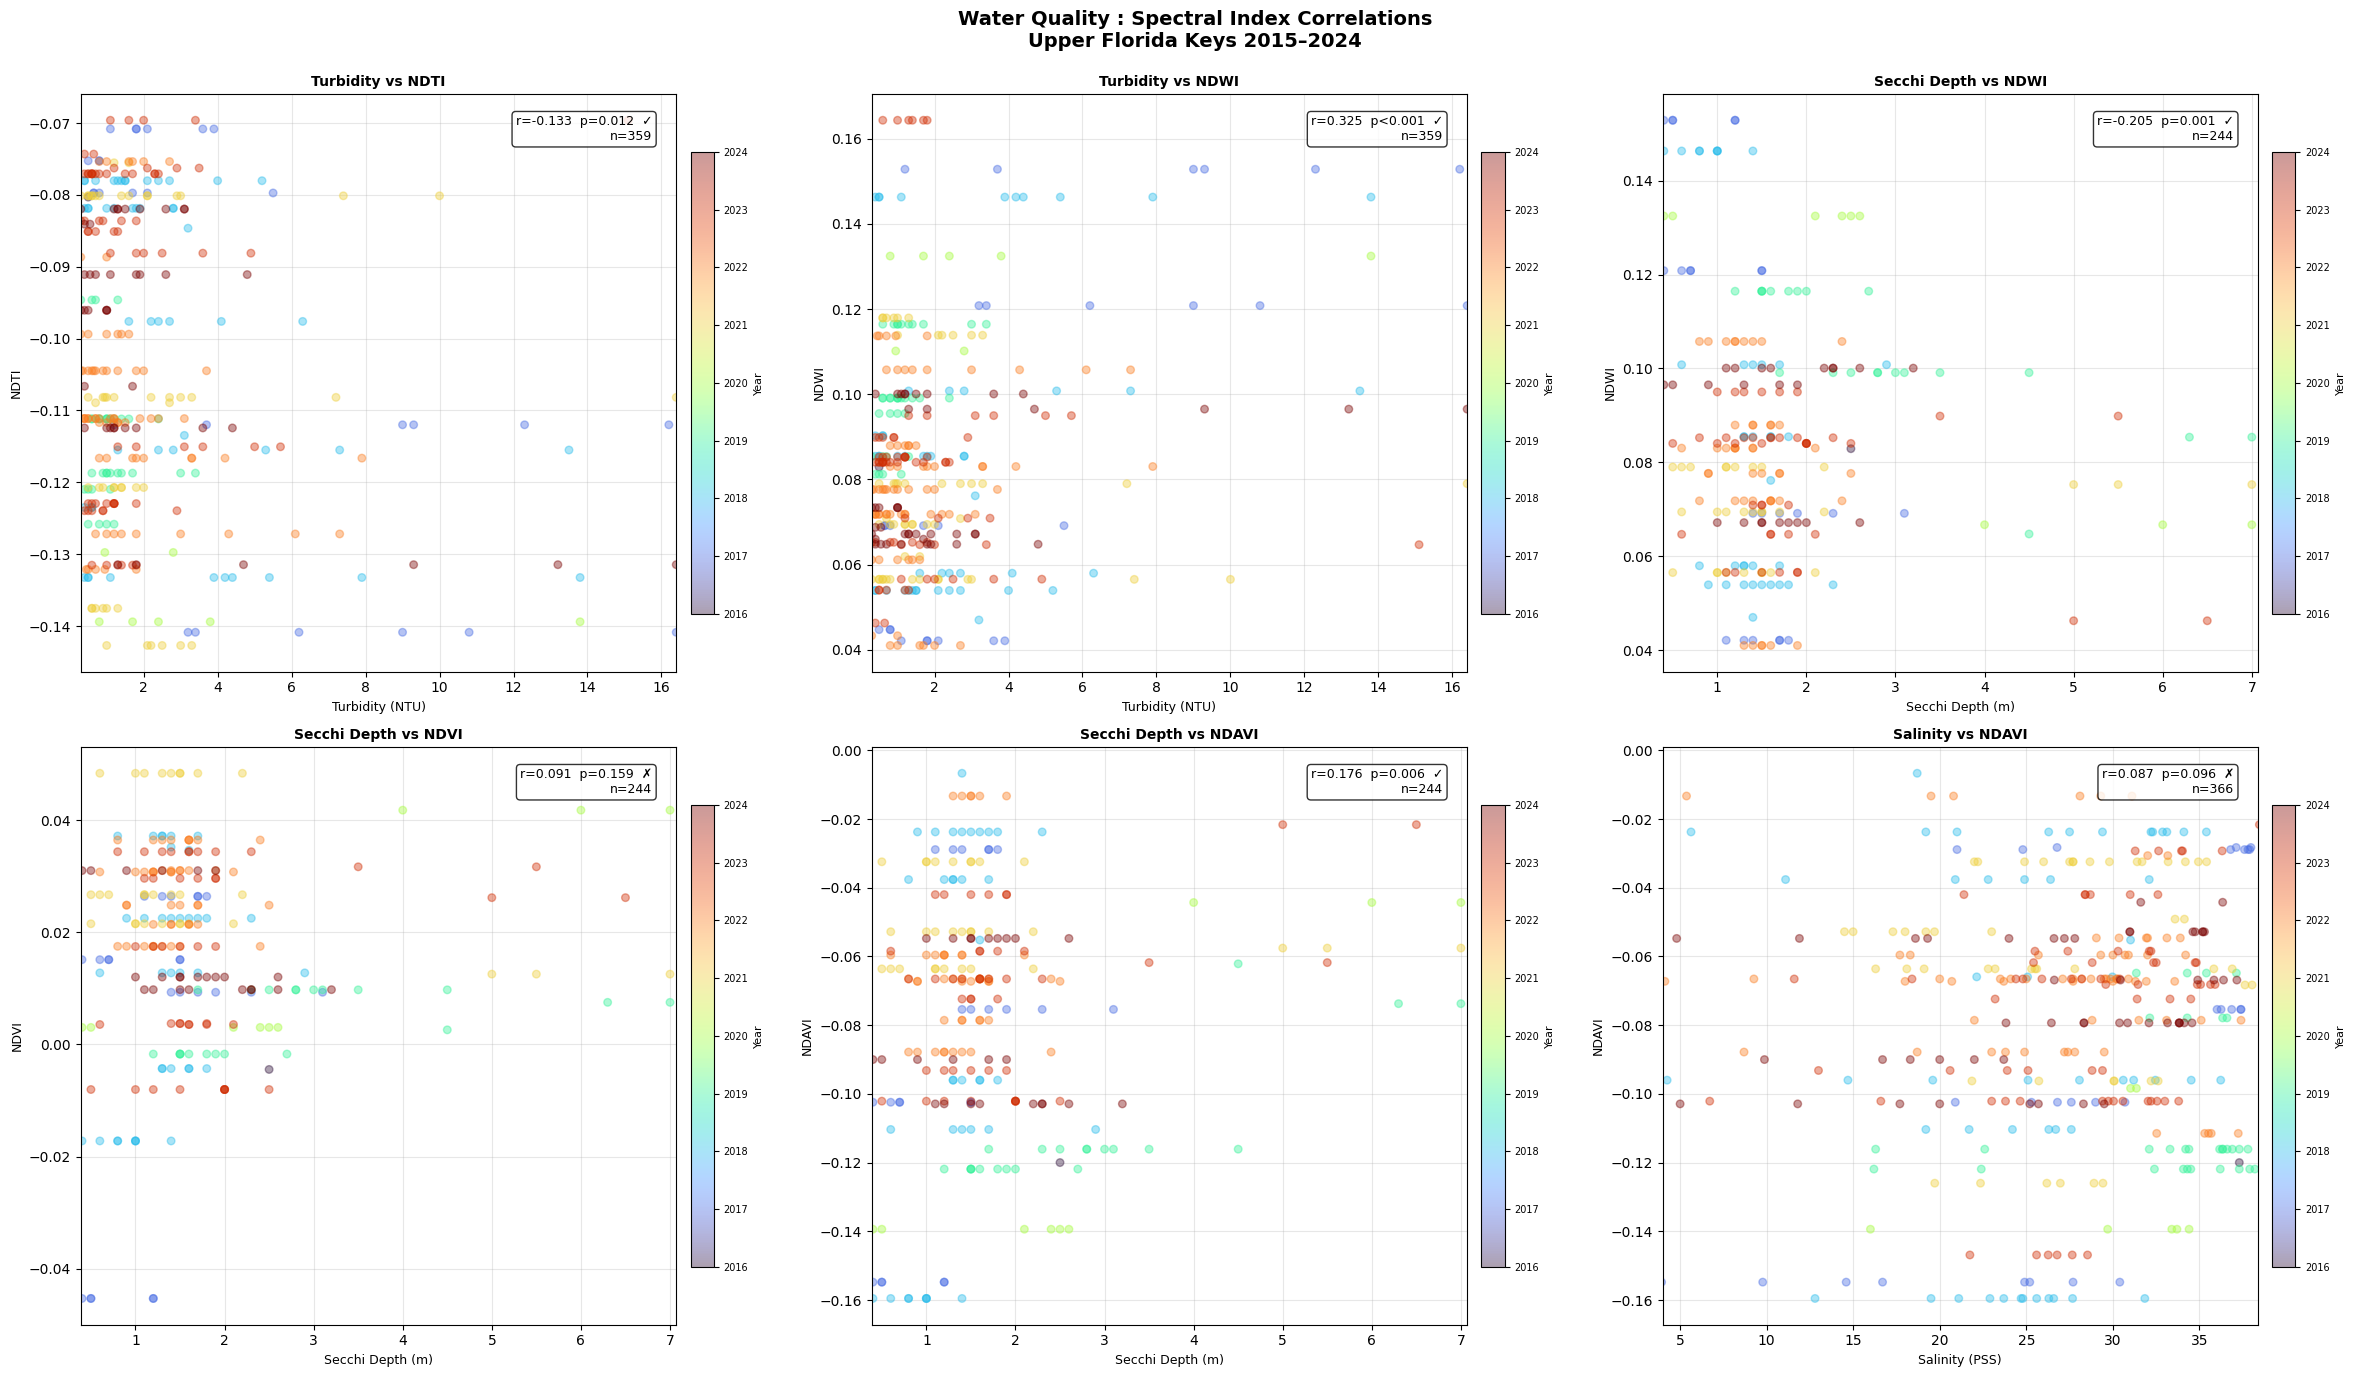

In [111]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for i, (wq_col, spec_col, label) in enumerate(pair_cols):
    ax = axes[i]
    paired = df_matched[[wq_col, spec_col]].dropna()
    x = paired[wq_col]
    y = paired[spec_col]

    # Compute regression INSIDE the loop
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_start, x_end = x.min(), x.max()
    y_start = slope * x_start + intercept
    y_end   = slope * x_end   + intercept

    # Scatter colored by year
    years = paired.index.year
    scatter = ax.scatter(x, y, c=years, cmap="turbo",
                        alpha=0.4, s=30, zorder=2)

    # Only draw arrow if significant
    if p < 0.05:
        ax.annotate("",
                    xy=(x_end, y_end),
                    xytext=(x_start, y_start),
                    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.0),
                    zorder=3)

    # Correlation annotation
    p_str = "p<0.001" if p < 0.001 else f"p={p:.3f}"
    sig_str = "✓" if p < 0.05 else "✗"
    ax.annotate(f"r={r:.3f}  {p_str}  {sig_str}\nn={len(paired)}",
                xy=(0.96, 0.92), xycoords="axes fraction",
                fontsize=9, color="black",
                ha="right",
                bbox=dict(boxstyle="round,pad=0.3",
                         facecolor="white", alpha=0.8))

    ax.set_xlabel(wq_col, fontsize=9)
    ax.set_ylabel(spec_col, fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlim(x.quantile(0.02), x.quantile(0.98))
    ax.grid(True, alpha=0.3)

    cbar = fig.colorbar(scatter, ax=ax, pad=0.02, shrink=0.8)
    cbar.set_label("Year", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Water Quality : Spectral Index Correlations\nUpper Florida Keys 2015–2024",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig("wq_spectral_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

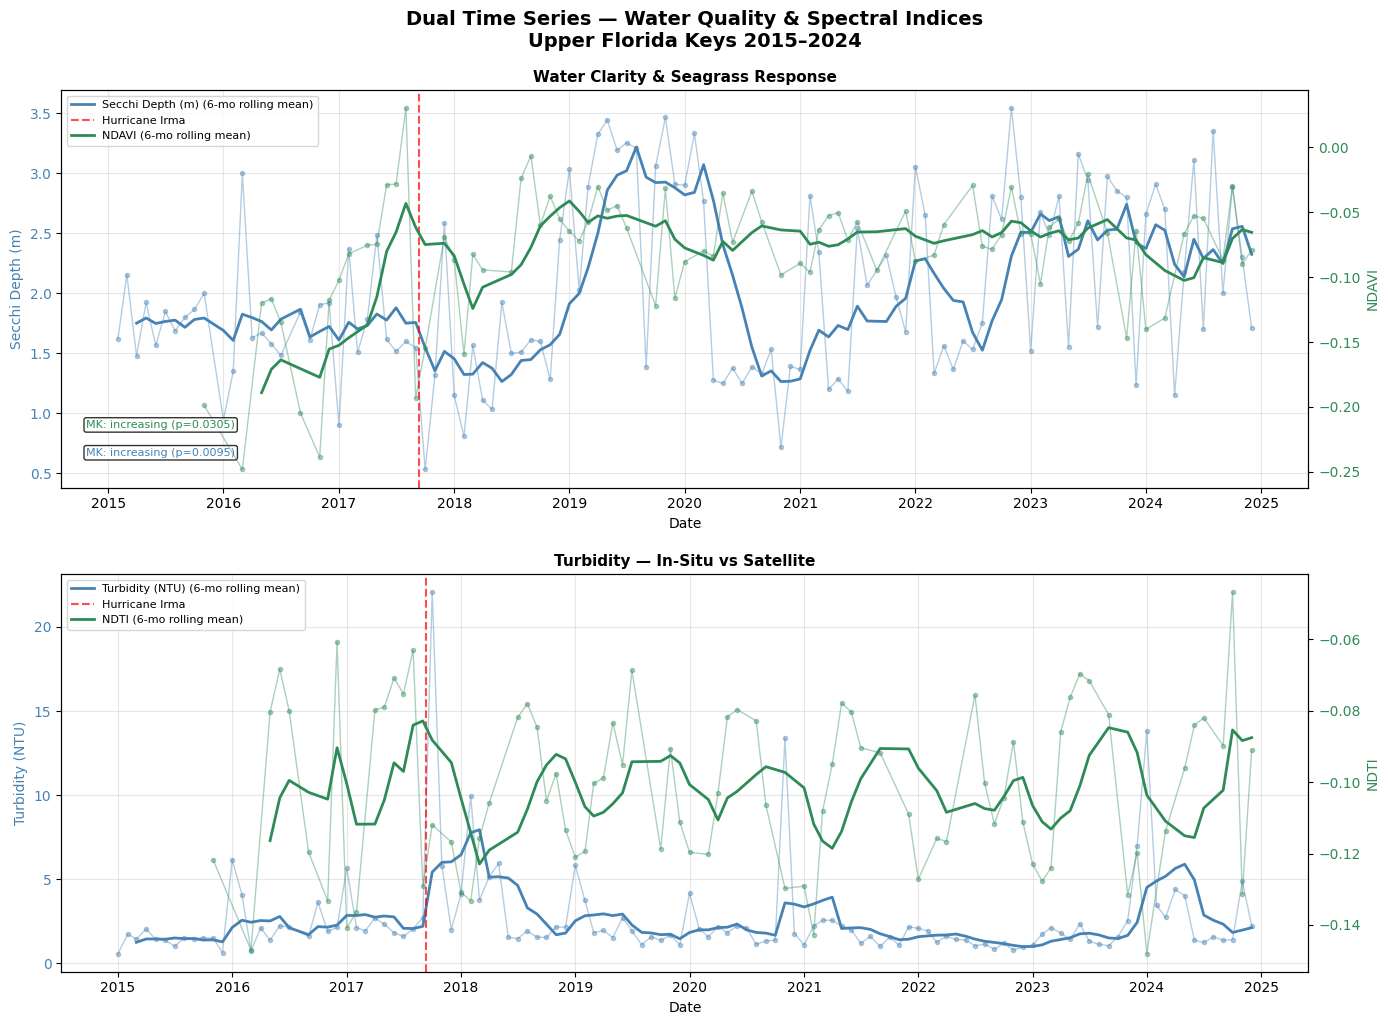

In [120]:
# FIGURE 2 — Dual Time Series
# Secchi Depth (WQ) + NDWI (Spectral) — water clarity
# Secchi Depth (WQ) + NDAVI (Spectral) — seagrass response

dual_pairs = [
    ("Secchi Depth (m)", "NDAVI", "Water Clarity & Seagrass Response"),
    ("Turbidity (NTU)",  "NDTI",  "Turbidity — In-Situ vs Satellite"),
]

fig, axes = plt.subplots(len(dual_pairs), 1, figsize=(14, 5 * len(dual_pairs)))

for i, (wq_col, spec_col, title) in enumerate(dual_pairs):
    ax1 = axes[i]
    ax2 = ax1.twinx()

    # WQ — left axis
    wq_series  = df_wq_monthly[wq_col].dropna()
    wq_rolling = wq_series.rolling(6, min_periods=3).mean()

    ax1.plot(wq_series.index, wq_series, color="steelblue",
             linewidth=1, alpha=0.4, marker="o", markersize=3)
    ax1.plot(wq_rolling.index, wq_rolling, color="steelblue",
             linewidth=2, label=f"{wq_col} (6-mo rolling mean)")
    ax1.set_ylabel(wq_col, color="steelblue", fontsize=10)
    ax1.tick_params(axis="y", labelcolor="steelblue")

    # Spectral — right axis
    spec_series  = df_spec_monthly[spec_col].dropna()
    spec_rolling = spec_series.rolling(6, min_periods=3).mean()

    ax2.plot(spec_series.index, spec_series, color="seagreen",
             linewidth=1, alpha=0.4, marker="o", markersize=3)
    ax2.plot(spec_rolling.index, spec_rolling, color="seagreen",
             linewidth=2, label=f"{spec_col} (6-mo rolling mean)")
    ax2.set_ylabel(spec_col, color="seagreen", fontsize=10)
    ax2.tick_params(axis="y", labelcolor="seagreen")

    # Hurricane Irma marker
    ax1.axvline(pd.Timestamp("2017-09-10"), color="red", linewidth=1.5,
                linestyle="--", alpha=0.7, label="Hurricane Irma")

    # Trend annotations for significant results
    mk_wq   = df_mk_wq[df_mk_wq["Parameter"] == wq_col]
    mk_spec = df_mk_spec[df_mk_spec["Index"] == spec_col]

    if not mk_wq.empty and mk_wq.iloc[0]["Significant"]:
        ax1.annotate(f"MK: {mk_wq.iloc[0]['Trend']} (p={mk_wq.iloc[0]['p-value']})",
                    xy=(0.02, 0.08), xycoords="axes fraction",
                    fontsize=8, color="steelblue",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

    if not mk_spec.empty and mk_spec.iloc[0]["Significant"]:
        ax2.annotate(f"MK: {mk_spec.iloc[0]['Trend']} (p={mk_spec.iloc[0]['p-value']})",
                    xy=(0.02, 0.15), xycoords="axes fraction",
                    fontsize=8, color="seagreen",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="upper left", fontsize=8)

    ax1.set_title(title, fontsize=11, fontweight="bold")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel("Date")

fig.suptitle("Dual Time Series — Water Quality & Spectral Indices\nUpper Florida Keys 2015–2024",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.94)
plt.savefig("dual_time_series.png", dpi=150, bbox_inches="tight")
plt.show()